# Previsão de Valor de Mercado — La Liga
**Dados:** Transfermarkt (valor, atributos pessoais) + Understat (stats de desempenho)  
**Target:** `log(market_value)` — distribuição lognormal, erros em escala relativa  
**Validação:** walk-forward temporal — treino 2017-2021, val 2022, teste 2023-2024

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import shap

base_path = Path('/Users/luccagazotto/Documents/Personal/ML Projects/Soccer player/Soccer_player_market_value')

df_raw = pd.read_parquet(base_path / 'panel_final.parquet')
print(f'Dataset carregado: {df_raw.shape}')

Dataset carregado: (6386, 30)


## 1. Feature Engineering

In [2]:
df = df_raw.copy()
df['year'] = df['year'].astype(int)

# ── Target ───────────────────────────────────────────────────────────────────
df = df[df['market_value'].notna() & (df['market_value'] > 0)].copy()
df['log_value'] = np.log(df['market_value'])

# ── Stats por 90 minutos ─────────────────────────────────────────────────────
per90 = lambda col: df[col] / (df['minutes'] / 90)

df['goals_p90']      = per90('goals')
df['xG_p90']         = per90('xG')
df['assists_p90']    = per90('assists')
df['xA_p90']         = per90('xA')
df['shots_p90']      = per90('shots')
df['key_passes_p90'] = per90('key_passes')
df['npxG_p90']       = per90('npxG')
df['xGChain_p90']    = per90('xGChain')
df['xGBuildup_p90']  = per90('xGBuildup')

# ── Atributos pessoais ───────────────────────────────────────────────────────
df['age2'] = df['age'] ** 2

foot_map = {'right': 1, 'left': 2, 'both': 3}
df['foot_enc'] = df['foot'].map(foot_map).fillna(0).astype(int)

def simplify_position(pos):
    if not isinstance(pos, str):
        return 'Unknown'
    p = pos.lower()
    if 'goalkeeper' in p:               return 'GK'
    if 'defender' in p:                 return 'DEF'
    if 'defensive midfield' in p:       return 'DM'
    if 'midfield' in p:                 return 'MID'
    if 'attack' in p or 'winger' in p:  return 'ATT'
    return 'Unknown'

df['pos_group'] = df['position'].apply(simplify_position)
pos_dummies = pd.get_dummies(df['pos_group'], prefix='posgrp', drop_first=True).astype(int)
df = pd.concat([df, pos_dummies], axis=1)

top_nat = df['nationality'].value_counts().head(10).index
df['nat_group'] = df['nationality'].apply(lambda x: x if x in top_nat else 'Other')
nat_dummies = pd.get_dummies(df['nat_group'], prefix='natgrp', drop_first=True).astype(int)
df = pd.concat([df, nat_dummies], axis=1)

# ── 1. Overperformance de xG ─────────────────────────────────────────────────
# Jogadores que consistentemente superam o esperado (finalizadores clínicos)
df['goals_minus_xG']   = df['goals'] - df['xG']
df['assists_minus_xA'] = df['assists'] - df['xA']

# ── 2. Percentil por posição e temporada ─────────────────────────────────────
# xG_p90 de 0.4 é mediano para ATT mas impossível para GK — normaliza
for col in ['xG_p90', 'xA_p90', 'npxG_p90', 'minutes']:
    df[f'{col}_pct'] = (
        df.groupby(['year', 'pos_group'])[col]
        .rank(pct=True, na_option='keep')
    )

# ── 3. Distância do pico de carreira por posição ─────────────────────────────
# Mercado paga prêmio por janela de revenda futura
PEAK_AGE = {'GK': 30, 'DEF': 28, 'DM': 28, 'MID': 27, 'ATT': 26, 'Unknown': 27}
df['years_to_peak'] = df.apply(
    lambda r: PEAK_AGE.get(r['pos_group'], 27) - r['age']
    if pd.notna(r['age']) else np.nan, axis=1
)
df['prime_window'] = (df['years_to_peak'].abs() <= 2).astype(int)

# ── 4. Tier do clube ─────────────────────────────────────────────────────────
# Jogadores do Real Madrid/Barça têm visibilidade que infla valor
club_avg = (
    df.groupby(['year', 'club'])['market_value']
    .median()
    .reset_index()
    .rename(columns={'market_value': 'club_med_value'})
)
df = df.merge(club_avg, on=['year', 'club'], how='left')
df['club_tier'] = df.groupby('year')['club_med_value'].transform(
    lambda x: pd.qcut(x, q=5, labels=False, duplicates='drop')
).astype(float)

# ── 5. Lag features (valor e stats do ano anterior) ──────────────────────────
# Maior preditor individual: o que o mercado pagou no ano passado
df = df.sort_values(['player_id', 'year']).reset_index(drop=True)

lag_cols = ['log_value', 'xG_p90', 'goals_p90', 'assists_p90', 'minutes']
for col in lag_cols:
    lagged = (
        df.groupby('player_id')[col]
        .shift(1)
    )
    # Só usa o lag se for do ano imediatamente anterior (sem gaps)
    year_diff = df.groupby('player_id')['year'].diff()
    df[f'{col}_lag1'] = lagged.where(year_diff == 1)

df['value_growth'] = df['log_value'] - df['log_value_lag1']  # crescimento YoY (log)

print(f'Dataset após feature engineering: {df.shape}')
new_features = ['goals_minus_xG', 'assists_minus_xA',
                'xG_p90_pct', 'xA_p90_pct', 'npxG_p90_pct', 'minutes_pct',
                'years_to_peak', 'prime_window',
                'club_med_value', 'club_tier',
                'log_value_lag1', 'xG_p90_lag1', 'goals_p90_lag1',
                'assists_p90_lag1', 'minutes_lag1', 'value_growth']
df[new_features].head(10)

Dataset após feature engineering: (5732, 74)


,goals_minus_xG,assists_minus_xA,xG_p90_pct,xA_p90_pct,npxG_p90_pct,minutes_pct,years_to_peak,prime_window,club_med_value,club_tier,log_value_lag1,xG_p90_lag1,goals_p90_lag1,assists_p90_lag1,minutes_lag1,value_growth
0,NaN,NaN,NaN,NaN,NaN,NaN,7.0,0,2500000.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,0.000000,0.000000,0.075521,0.096354,0.075521,0.005208,9.0,0,2500000.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2,0.000000,0.000000,0.082447,0.090426,0.082447,0.053191,8.0,0,2000000.0,1.0,11.512925,0.000000,0.000000,0.000000,1.0,0.000000
3,0.000000,0.000000,0.048023,0.067797,0.048023,0.112994,8.0,0,2000000.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
4,-0.659258,3.261456,0.526316,0.842105,0.526316,0.842105,2.0,1,6000000.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN
5,-0.314193,-0.605911,0.437500,0.843750,0.500000,0.312500,1.0,1,7500000.0,3.0,17.034386,0.024815,0.000000,0.188206,2391.0,-0.223144
6,0.594333,-0.592508,0.956522,0.673913,0.956522,0.565217,0.0,1,3500000.0,2.0,16.811243,0.031560,0.000000,0.000000,896.0,0.000000
7,-1.056291,1.293728,0.953488,0.906977,0.953488,0.651163,-1.0,1,3000000.0,2.0,16.811243,0.104123,0.148148,0.000000,1215.0,-0.356675
8,-0.331784,-1.493770,0.945946,0.675676,0.972973,0.810811,-2.0,1,4000000.0,2.0,16.454568,0.151719,0.099283,0.148924,1813.0,0.133531
9,0.660829,2.166032,0.658537,0.902439,0.682927,0.365854,-3.0,0,5000000.0,2.0,16.588099,0.121009,0.108959,0.000000,2478.0,-0.980829


## 2. Definição das Features e Split Temporal

In [3]:
PERSONAL_FEATURES = ['age', 'age2', 'height', 'foot_enc']

STAT_FEATURES = [
    'minutes', 'games',
    'goals_p90', 'xG_p90', 'assists_p90', 'xA_p90',
    'shots_p90', 'key_passes_p90', 'npxG_p90',
    'xGChain_p90', 'xGBuildup_p90',
]

ENGINEERED_FEATURES = [
    # overperformance
    'goals_minus_xG', 'assists_minus_xA',
    # percentil por posição/temporada
    'xG_p90_pct', 'xA_p90_pct', 'npxG_p90_pct', 'minutes_pct',
    # pico de carreira
    'years_to_peak', 'prime_window',
    # tier do clube
    'club_med_value', 'club_tier',
    # lags
    'log_value_lag1', 'xG_p90_lag1', 'goals_p90_lag1',
    'assists_p90_lag1', 'minutes_lag1', 'value_growth',
]

POS_FEATURES = [c for c in df.columns if c.startswith('posgrp_')]
NAT_FEATURES = [c for c in df.columns if c.startswith('natgrp_')]

FEATURES = PERSONAL_FEATURES + STAT_FEATURES + ENGINEERED_FEATURES + POS_FEATURES + NAT_FEATURES
TARGET   = 'log_value'

print(f'Total features: {len(FEATURES)}')
print(FEATURES)

train = df[df['year'] <= 2021].copy()
val   = df[df['year'] == 2022].copy()
test  = df[df['year'] >= 2023].copy()

print(f'\nTreino (2017-2021): {len(train)} jogadores')
print(f'Validação (2022):   {len(val)} jogadores')
print(f'Teste (2023-2024):  {len(test)} jogadores')

def get_Xy(subset):
    X = subset[FEATURES].copy()
    y = subset[TARGET].copy()
    mask = y.notna()
    return X[mask], y[mask], subset[mask]

X_train, y_train, train_ = get_Xy(train)
X_val,   y_val,   val_   = get_Xy(val)
X_test,  y_test,  test_  = get_Xy(test)

Total features: 45
['age', 'age2', 'height', 'foot_enc', 'minutes', 'games', 'goals_p90', 'xG_p90', 'assists_p90', 'xA_p90', 'shots_p90', 'key_passes_p90', 'npxG_p90', 'xGChain_p90', 'xGBuildup_p90', 'goals_minus_xG', 'assists_minus_xA', 'xG_p90_pct', 'xA_p90_pct', 'npxG_p90_pct', 'minutes_pct', 'years_to_peak', 'prime_window', 'club_med_value', 'club_tier', 'log_value_lag1', 'xG_p90_lag1', 'goals_p90_lag1', 'assists_p90_lag1', 'minutes_lag1', 'value_growth', 'posgrp_DEF', 'posgrp_DM', 'posgrp_GK', 'posgrp_MID', 'natgrp_Brazil', 'natgrp_Colombia', 'natgrp_France', 'natgrp_Morocco', 'natgrp_Other', 'natgrp_Portugal', 'natgrp_Senegal', 'natgrp_Serbia', 'natgrp_Spain', 'natgrp_Uruguay']

Treino (2017-2021): 3093 jogadores
Validação (2022):   694 jogadores
Teste (2023-2024):  1945 jogadores


## 3. Baseline — Ridge Regression

In [4]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

ridge_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   Ridge(alpha=10)),
])

ridge_pipe.fit(X_train, y_train)

def evaluate(name, model, X, y):
    pred_log = model.predict(X)
    pred_eur = np.exp(pred_log)
    true_eur = np.exp(y)

    rmse = np.sqrt(np.mean((y - pred_log) ** 2))
    mae  = mean_absolute_error(y, pred_log)
    r2   = r2_score(y, pred_log)
    mape = np.median(np.abs((true_eur - pred_eur) / true_eur)) * 100

    print(f'  {name}')
    print(f'    R²:           {r2:.3f}')
    print(f'    RMSE (log):   {rmse:.3f}')
    print(f'    MAE  (log):   {mae:.3f}')
    print(f'    MAPE (euros): {mape:.1f}%')

print('=== RIDGE ===')
evaluate('Treino', ridge_pipe, X_train, y_train)
evaluate('Val',    ridge_pipe, X_val,   y_val)
evaluate('Teste',  ridge_pipe, X_test,  y_test)

=== RIDGE ===
  Treino
    R²:           0.635
    RMSE (log):   0.966
    MAE  (log):   0.729
    MAPE (euros): 48.9%
  Val
    R²:           0.590
    RMSE (log):   1.125
    MAE  (log):   0.804
    MAPE (euros): 45.4%
  Teste
    R²:           0.606
    RMSE (log):   1.053
    MAE  (log):   0.780
    MAPE (euros): 48.1%


## 4. XGBoost

In [5]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=30,
    eval_metric='rmse',
    verbosity=0,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print('=== XGBOOST ===')
evaluate('Treino', xgb_model, X_train, y_train)
evaluate('Val',    xgb_model, X_val,   y_val)
evaluate('Teste',  xgb_model, X_test,  y_test)

=== XGBOOST ===
  Treino
    R²:           0.849
    RMSE (log):   0.621
    MAE  (log):   0.410
    MAPE (euros): 23.8%
  Val
    R²:           0.783
    RMSE (log):   0.818
    MAE  (log):   0.501
    MAPE (euros): 25.7%
  Teste
    R²:           0.765
    RMSE (log):   0.814
    MAE  (log):   0.519
    MAPE (euros): 27.9%


## 5. Comparação Visual — Predito vs Real

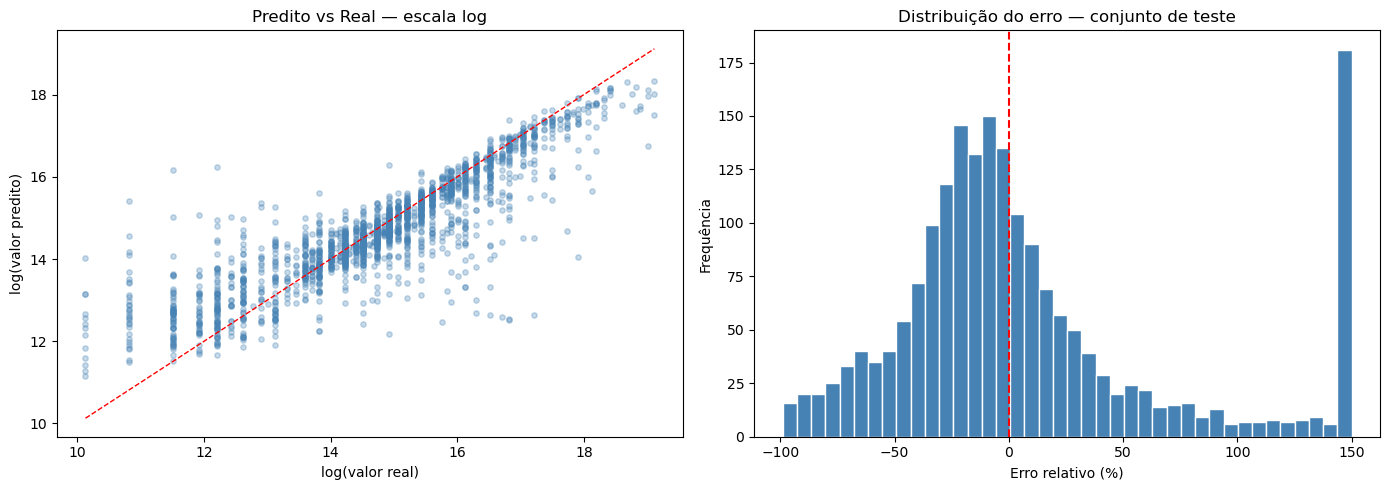

In [6]:
pred_test_log = xgb_model.predict(X_test)
pred_test_eur = np.exp(pred_test_log) / 1e6  # em milhões
true_test_eur = np.exp(y_test) / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predito vs Real (log scale)
ax = axes[0]
ax.scatter(y_test, pred_test_log, alpha=0.3, s=15, color='steelblue')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlabel('log(valor real)')
ax.set_ylabel('log(valor predito)')
ax.set_title('Predito vs Real — escala log')

# Distribuição dos erros em %
ax = axes[1]
pct_error = (pred_test_eur - true_test_eur) / true_test_eur * 100
ax.hist(pct_error.clip(-150, 150), bins=40, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', lw=1.5, linestyle='--')
ax.set_xlabel('Erro relativo (%)')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição do erro — conjunto de teste')

plt.tight_layout()
plt.savefig(base_path / 'pred_vs_real.png', dpi=150)
plt.show()

## 6. Interpretabilidade — SHAP

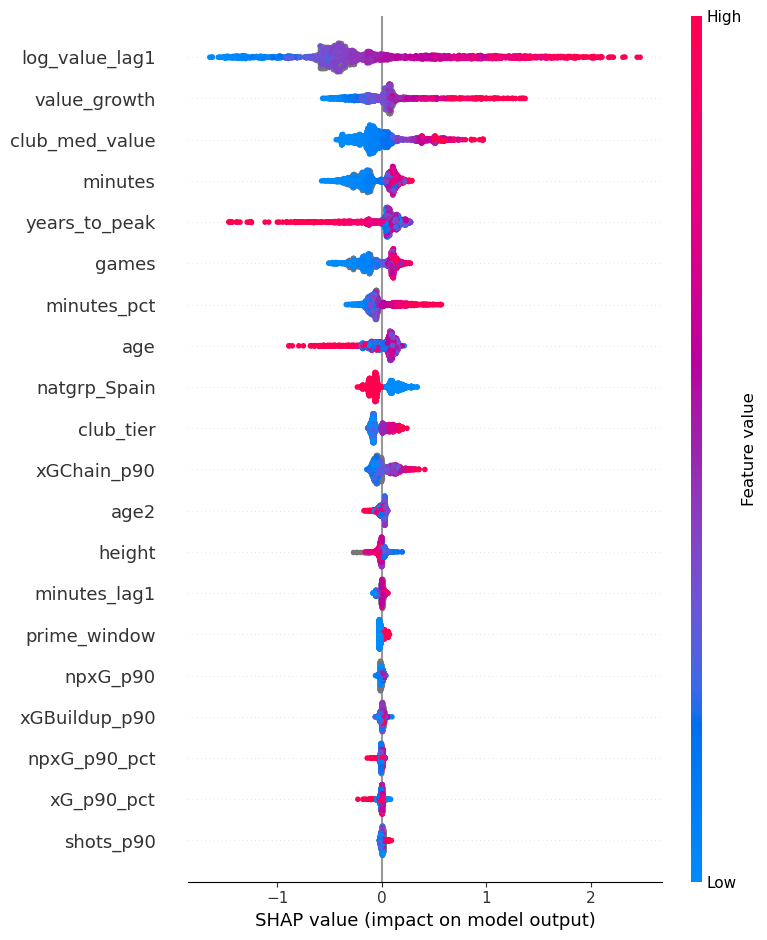

In [7]:
explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer.shap_values(X_test)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_test, feature_names=FEATURES, show=False)
plt.tight_layout()
plt.savefig(base_path / 'shap_summary.png', dpi=150)
plt.show()

## 7. Jogadores mais sub e sobrevalorizados

In [8]:
results = test_.copy()
results['pred_log']    = xgb_model.predict(X_test)
results['pred_value']  = np.exp(results['pred_log'])
results['error_pct']   = (results['pred_value'] - results['market_value']) / results['market_value'] * 100

cols_show = ['player_name', 'year', 'club', 'pos_group', 'age',
             'market_value', 'pred_value', 'error_pct']

print('=== TOP 10 SUBVALORIZADOS (modelo acha que valem mais) ===')
display(results.nlargest(10, 'error_pct')[cols_show].assign(
    market_value=lambda x: (x['market_value']/1e6).round(1).astype(str) + 'M',
    pred_value  =lambda x: (x['pred_value']/1e6).round(1).astype(str) + 'M',
    error_pct   =lambda x: x['error_pct'].round(0).astype(int).astype(str) + '%',
))

print('\n=== TOP 10 SOBREVALORIZADOS (modelo acha que valem menos) ===')
display(results.nsmallest(10, 'error_pct')[cols_show].assign(
    market_value=lambda x: (x['market_value']/1e6).round(1).astype(str) + 'M',
    pred_value  =lambda x: (x['pred_value']/1e6).round(1).astype(str) + 'M',
    error_pct   =lambda x: x['error_pct'].round(0).astype(int).astype(str) + '%',
))

=== TOP 10 SUBVALORIZADOS (modelo acha que valem mais) ===


,player_name,year,club,pos_group,age,market_value,pred_value,error_pct
5288,Dani Rodríguez,2024,FC Barcelona,ATT,19.0,0.1M,10.4M,10309%
5420,Diego López,2023,Getafe CF,MID,22.0,0.0M,4.9M,9662%
4207,Sergio Guerrero,2023,Atlético de Madrid,MID,24.0,0.2M,11.3M,5529%
110,Joaquín Panichelli,2023,Deportivo Alavés,ATT,21.0,0.0M,1.2M,4833%
403,Álvaro García Pascual,2024,Sevilla FC,ATT,22.0,0.0M,2.1M,4071%
5573,Jon García,2024,CA Osasuna,MID,21.0,0.1M,3.3M,3237%
106,Ander Sánchez,2023,Deportivo Alavés,MID,19.0,0.0M,1.4M,2722%
3825,Jordi Martín,2023,Getafe CF,DEF,22.0,0.0M,1.3M,2582%
4216,Adrián Rodríguez,2023,Deportivo Alavés,GK,23.0,0.2M,3.5M,2259%
3,Pablo López,2024,Valencia CF,ATT,18.0,0.0M,0.5M,1956%



=== TOP 10 SOBREVALORIZADOS (modelo acha que valem menos) ===


,player_name,year,club,pos_group,age,market_value,pred_value,error_pct
11,Vitor Reis,2025,Girona FC,DEF,19.0,30.0M,0.3M,-99%
5703,Samu Aghehowa,2023,Deportivo Alavés,ATT,19.0,20.0M,0.3M,-99%
5702,Samu Aghehowa,2023,Granada CF,ATT,19.0,20.0M,0.3M,-99%
5416,Dean Huijsen,2024,Real Madrid,DEF,19.0,18.0M,0.3M,-98%
5648,Rodrigo Mendoza,2025,Elche CF,MID,20.0,15.0M,0.3M,-98%
5246,Álvaro Carreras,2025,Real Madrid,DEF,22.0,60.0M,1.3M,-98%
400,Jan Virgili,2025,RCD Mallorca,ATT,19.0,12.0M,0.3M,-97%
5245,Álvaro Carreras,2023,Granada CF,DEF,20.0,7.0M,0.3M,-96%
4210,Hannibal,2023,Sevilla FC,MID,20.0,12.0M,0.4M,-96%
4676,Carlos Álvarez,2025,Levante UD,ATT,22.0,15.0M,0.6M,-96%


## 8. Salvar modelo e resultados

In [9]:
import pickle

with open(base_path / 'xgb_model.pkl', 'wb') as f:
    pickle.dump({'model': xgb_model, 'features': FEATURES}, f)

results.to_parquet(base_path / 'test_predictions.parquet', index=False)

print('Salvo:')
print('  xgb_model.pkl')
print('  test_predictions.parquet')
print('  pred_vs_real.png')
print('  shap_summary.png')

Salvo:
  xgb_model.pkl
  test_predictions.parquet
  pred_vs_real.png
  shap_summary.png
